In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

data = pd.read_csv('/Dataset/FPT_1m_020124150526.csv')
data.head()

,time,open,high,low,close,volume
0,2024-01-02 09:15:00,70.92,70.92,70.40,70.92,51200
1,2024-01-02 09:16:00,70.92,70.92,70.62,70.62,6700
2,2024-01-02 09:17:00,70.62,70.70,70.62,70.70,1200
3,2024-01-02 09:18:00,70.70,70.84,70.70,70.70,1400
4,2024-01-02 09:19:00,70.70,70.70,70.70,70.70,16500


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131422 entries, 0 to 131421
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    131422 non-null  object 
 1   open    131422 non-null  float64
 2   high    131422 non-null  float64
 3   low     131422 non-null  float64
 4   close   131422 non-null  float64
 5   volume  131422 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 6.0+ MB


In [8]:
data.shape

(131422, 6)

# Chỉnh dạng dữ liệu + Lọc dữ liệu + Mô tả dữ liệu

In [7]:
data['time'] = pd.to_datetime(data['time'], format='%Y-%m-%d %H:%M:%S')

In [9]:
# check null values
data.isnull().sum()

time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [11]:
# check duplicated values
data.duplicated().sum()

np.int64(0)

In [68]:
data.describe()

,time,open,high,low,close,volume
count,131422,131422.000000,131422.000000,131422.000000,131422.000000,1.314220e+05
mean,2025-03-11 18:13:27.894872832,100.379113,100.436913,100.318832,100.378823,2.965976e+04
min,2024-01-02 09:15:00,68.870000,68.940000,68.870000,68.870000,1.000000e+02
25%,2024-08-09 09:21:15,92.600000,92.700000,92.540000,92.640000,5.800000e+03
50%,2025-03-12 13:52:30,100.550000,100.610000,100.450000,100.550000,1.390000e+04
75%,2025-10-10 11:20:45,111.690000,111.780000,111.690000,111.690000,3.140000e+04
max,2026-05-15 14:45:00,133.030000,133.120000,132.950000,133.030000,8.274200e+06
std,NaN,15.260729,15.263095,15.260295,15.260320,6.793605e+04


In [69]:
data['volume'].min(), data['volume'].max()

(100, 8274200)

In [70]:
data[data['volume'] == data['volume'].min()]

,time,open,high,low,close,volume
64,2024-01-02 10:23:00,70.55,70.55,70.55,70.55,100
90,2024-01-02 10:55:00,70.40,70.40,70.40,70.40,100
145,2024-01-02 13:22:00,70.26,70.26,70.26,70.26,100
152,2024-01-02 13:30:00,70.26,70.26,70.26,70.26,100
164,2024-01-02 13:45:00,70.33,70.33,70.33,70.33,100
...,...,...,...,...,...,...
118125,2026-02-12 09:48:00,98.70,98.70,98.70,98.70,100
124719,2026-04-01 10:31:00,75.60,75.60,75.60,75.60,100
125419,2026-04-06 10:53:00,73.90,73.90,73.90,73.90,100
125441,2026-04-06 11:15:00,73.90,73.90,73.90,73.90,100


In [71]:
data[data['volume'] == data['volume'].max()]

,time,open,high,low,close,volume
95275,2025-09-19 14:45:00,101.94,101.94,101.94,101.94,8274200


# Exploratory Data Analysis

In [86]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure
import math
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [43]:
class LinePlot:
    def __init__(self, df:pd.DataFrame):
        self.df = df

    @staticmethod
    def readable_numbers(x: float) -> str:
        """
        takes a large number and formats it into K,M to make it more readable

        Args
            x: float value to format

        Returns
            str: formatted string
        """
        if x >= 1e6:
            s = '{:1.2f}M'.format(x*1e-6)
        else:
            s = '{:1.2f}K'.format(x*1e-3)
        return s
    
    def set_locator(self, axes: Axes):
        """
        Format x, y ticklabels into more readable form

        Args
            axes: matplotlib axes to format x, y ticklabels
        """
        def is_number(x):
            x = x.replace('−', '-')
            try:
                float(x)
                return True
            except ValueError:
                return False
    
        x_ticklabels = [tick.get_text() for tick in axes.get_xticklabels()]
        y_ticklabels = [tick.get_text() for tick in axes.get_yticklabels()]
    
        formatter = FuncFormatter(lambda val, pos: self.readable_numbers(val))

        if is_number(x_ticklabels[0]) == True:
            axes.xaxis.set_major_formatter(formatter)
        if is_number(y_ticklabels[0]) == True:
            axes.yaxis.set_major_formatter(formatter)
    
    def single_plot(
        self,
        x_axis: str,
        y_axis: str,
        hue: str | None = None,
        style: str | None = None,
        size: str | None = None,
        kwarg: dict | None = None,
        readable_label: bool = False,
        ax: Axes = None
    ) -> Axes:
        """
        Draw a visually stunning and readable line plot.
    
        Args:
            x_axis: categorical or numeric column for X-axis
            y_axis: numeric column for Y-axis
            hue: column for line colors (group)
            style: column for line styles (e.g., dashed, dotted)
            size: column for line thickness variation
            kwarg: additional seaborn.lineplot arguments
            readable_label: whether to format axes tick labels into readable form
            ax: matplotlib Axes to draw plot on
        """
    
        if ax is None:
            ax = plt.gca()
            fig = ax.get_figure()
            fig.set_size_inches(10, 6)
        if kwarg is None:
            kwarg = {}

        if hue is not None:
            palette='viridis'
        else:
            palette=None
        # --- 🎨 Line Plot ---
        line = sns.lineplot(
            data=self.df,
            x=x_axis,
            y=y_axis,
            hue=hue,
            style=style,
            size=size,
            ax=ax,
            # marker="o",             # ✅ Add circle markers to each data point
            linewidth=2.2,          # ✅ Slightly thicker lines
            # markersize=4,           # ✅ Larger markers for visibility
            alpha=0.9,              # ✅ Soft transparency for overlapping lines
            palette=palette,      # ✅ Modern, readable color palette
            **kwarg
        )
    
        # --- 🎭 Title & Axis Labels ---
        ax.set_title(
            f"{y_axis} vs {x_axis}",
            fontsize=12,
            fontweight="regular",
            # fontname="Times New Roman",
            # pad=15
        )
        ax.set_xlabel(x_axis, fontsize=12, labelpad=5) # fontname="Times New Roman"
        ax.set_ylabel(y_axis, fontsize=12, labelpad=10) # fontname="Times New Roman"
    
        # --- 📏 Tick Formatting ---
        ax.tick_params(axis="x", rotation=0, labelsize=11)
        ax.tick_params(axis="y", rotation=0, labelsize=11)
        ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    
        # --- 🎨 Legend ---
        if hue or style or size:
            leg = ax.legend(
                title="Legend",
                title_fontsize=11,
                fontsize=10,
                loc="best",
                frameon=False,
                fancybox=True,
                framealpha=0.9,
            )
            leg.get_frame().set_linewidth(0.7)
            leg.get_frame().set_edgecolor("gray")
    
        # --- 📊 Optional: Format Large Axis Labels ---
        if readable_label:
            self.set_locator(ax)
    
        # --- 💅 Aesthetic Cleanup ---
        sns.despine(ax=ax, top=True, right=True)
    
        return line

    def multiple_plots(self, x_axis_list: list[str], y_axis_list: list[str], hue_list: list[str|None], 
                       kwarg: dict, plots_each_row: int, size_list: list[str|None], style_list: list[str|None],
                       readable_label: bool = False) -> (Figure, np.array([Axes])):
        """
        Draw multiple plots

        Args
            Same as single_plot
            y_axis_list: list of columns for y axis
            x_axis_list: list of columns for x axis
            hue_list
            size_list
            style_list
            plots_each_row: number of plots for each row in matplotlib figure
            kwarg: additional seaborn.lineplot arguments
        """
        
        combination = list(zip(x_axis_list, y_axis_list, hue_list, size_list, style_list))
        
        length = len(combination)
        number_rows = math.ceil(length / plots_each_row)
    
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 12)) #sharey=True: same y_axis scale
        axes = np.array(axes).reshape(number_rows, plots_each_row)
    
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
        for coor, com in zip(coordinates, combination):
            x, y, hue, size, style = com
            ax = axes[coor]
            self.single_plot(
                x_axis=x,
                y_axis=y,
                hue=hue,
                size=size,
                style=style,
                readable_label=readable_label,
                kwarg=kwarg,
                ax=ax
            )
    
        # hide any unused axes
        for coor in coordinates[length:]:
            fig.delaxes(axes[coor])

        return fig, axes

In [89]:
class BoxPlot:
    """
    Create single and multiple box plots
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df

    @staticmethod
    def readable_numbers(x: float) -> str:
        """
        takes a large number and formats it into K,M to make it more readable

        Args
            x: float value to format

        Returns
            str: formatted string
        """
        if x >= 1e6:
            s = '{:1.2f}M'.format(x*1e-6)
        else:
            s = '{:1.2f}K'.format(x*1e-3)
        return s

    def set_locator(self, axes: Axes):
        """
        Format x, y ticklabels into more readable form

        Args
            axes: matplotlib axes to format x, y ticklabels
        """
        def is_number(x):
            x = x.replace('−', '-')
            try:
                float(x)
                return True
            except ValueError:
                return False
    
        x_ticklabels = [tick.get_text() for tick in axes.get_xticklabels()]
        y_ticklabels = [tick.get_text() for tick in axes.get_yticklabels()]

        formatter = FuncFormatter(lambda val, pos: self.readable_numbers(val))

        if is_number(x_ticklabels[0]) == True:
            axes.xaxis.set_major_formatter(formatter)
        if is_number(y_ticklabels[0]) == True:
            axes.yaxis.set_major_formatter(formatter)

    def single_plot(
        self,
        x_axis: str,
        y_axis: str | None,
        hue: str | None,
        kwarg: dict | None = None,
        readable_label: bool = False,
        ax: Axes = None
    ) -> Axes:
        """
        Draw a beautiful and readable Box Plot.
    
        Args:
            x_axis: column needed
            y_axis: column needed
            hue: column needed
            dimension: '1d' for single variable, '2d' for grouped boxplot
            readable_label: whether to format x/y tick labels for readability
            ax: matplotlib axes to draw plot
            kwarg: additional seaborn arguments
        """
        
        if ax is None:
            ax = plt.gca()
        if kwarg is None:
            kwarg = {}
            
        # --- Styling palette and defaults ---
        sns.set_style("whitegrid")  # clean background
        palette = kwarg.pop("palette", "Set2") if kwarg else "Set2"
            
        if hue is None:
            palette=None
        
        box = sns.boxplot(
            data=self.df,
            x=x_axis,
            y=y_axis,
            hue=hue,
            ax=ax,
            palette=palette,
            width=0.6,
            fliersize=3,
            linewidth=1.2,
            boxprops={"alpha": 0.8},
            medianprops={"color": "black", "linewidth": 1},
            whiskerprops={"linewidth": 1},
            capprops={"linewidth": 1},
            **kwarg
        )
        
        if y_axis is None:
            y_axis = ""
        
        ax.set_xlabel(x_axis, fontsize=13, labelpad=8)
        ax.set_ylabel(y_axis, fontsize=13, labelpad=8)

        if hue is not None and y_axis != "":
            ax.legend(
                title=hue if hue else "",
                frameon=True,
                fancybox=True,
                framealpha=0.8,
                fontsize=11,
                title_fontsize=12,
                loc="best",
            )
    
        # --- Titles & Ticks ---
        ax.set_title(
            f"Box Plot",
            fontdict={"fontsize": 12, "fontweight": "regular"}, # "fontname": "Times New Roman"
            pad=15
        )
        ax.tick_params(axis="x", labelrotation=0, labelsize=11)
        ax.tick_params(axis="y", labelrotation=0, labelsize=11)
    
        # --- Optional: readable tick labels ---
        if readable_label:
            self.set_locator(ax)
    
        # --- Clean up look ---
        sns.despine(ax=ax, top=True, right=True)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
    
        return box
    
    def multiple_plots(self, y_axis_list: list[str|None], x_axis_list: list[str], kwarg: dict|None,
                       hue_list: list[str|None], plots_each_row: int, 
                       readable_label: bool = False) -> (Figure, np.array([Axes])):
        """
        Draw multiple box plots
        
        Args
            Same as single_plot
            y_axis_list: list of columns for y axis
            plots_each_row: number of plots for each row in matplotlib figure
        """
        combination = list(zip(x_axis_list, y_axis_list, hue_list))
        
        length = len(combination)
        number_rows = math.ceil(length / plots_each_row)
    
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),
                                sharey=True) # same y_axis scale
        axes = np.array(axes).reshape(number_rows, plots_each_row)
    
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
        for coor, com in zip(coordinates, combination):
            x, y, hue = com
            ax = axes[coor]
            self.single_plot(
                x_axis=x,
                y_axis=y,
                hue=hue,
                readable_label=readable_label,
                kwarg=kwarg,
                ax=ax
            )
    
        # hide any unused axes
        for coor in coordinates[length:]:
            fig.delaxes(axes[coor])
    
        fig.tight_layout()

        return fig, axes

In [44]:
line_plotter = LinePlot(data)

In [17]:
data.head()

,time,open,high,low,close,volume
0,2024-01-02 09:15:00,70.92,70.92,70.40,70.92,51200
1,2024-01-02 09:16:00,70.92,70.92,70.62,70.62,6700
2,2024-01-02 09:17:00,70.62,70.70,70.62,70.70,1200
3,2024-01-02 09:18:00,70.70,70.84,70.70,70.70,1400
4,2024-01-02 09:19:00,70.70,70.70,70.70,70.70,16500


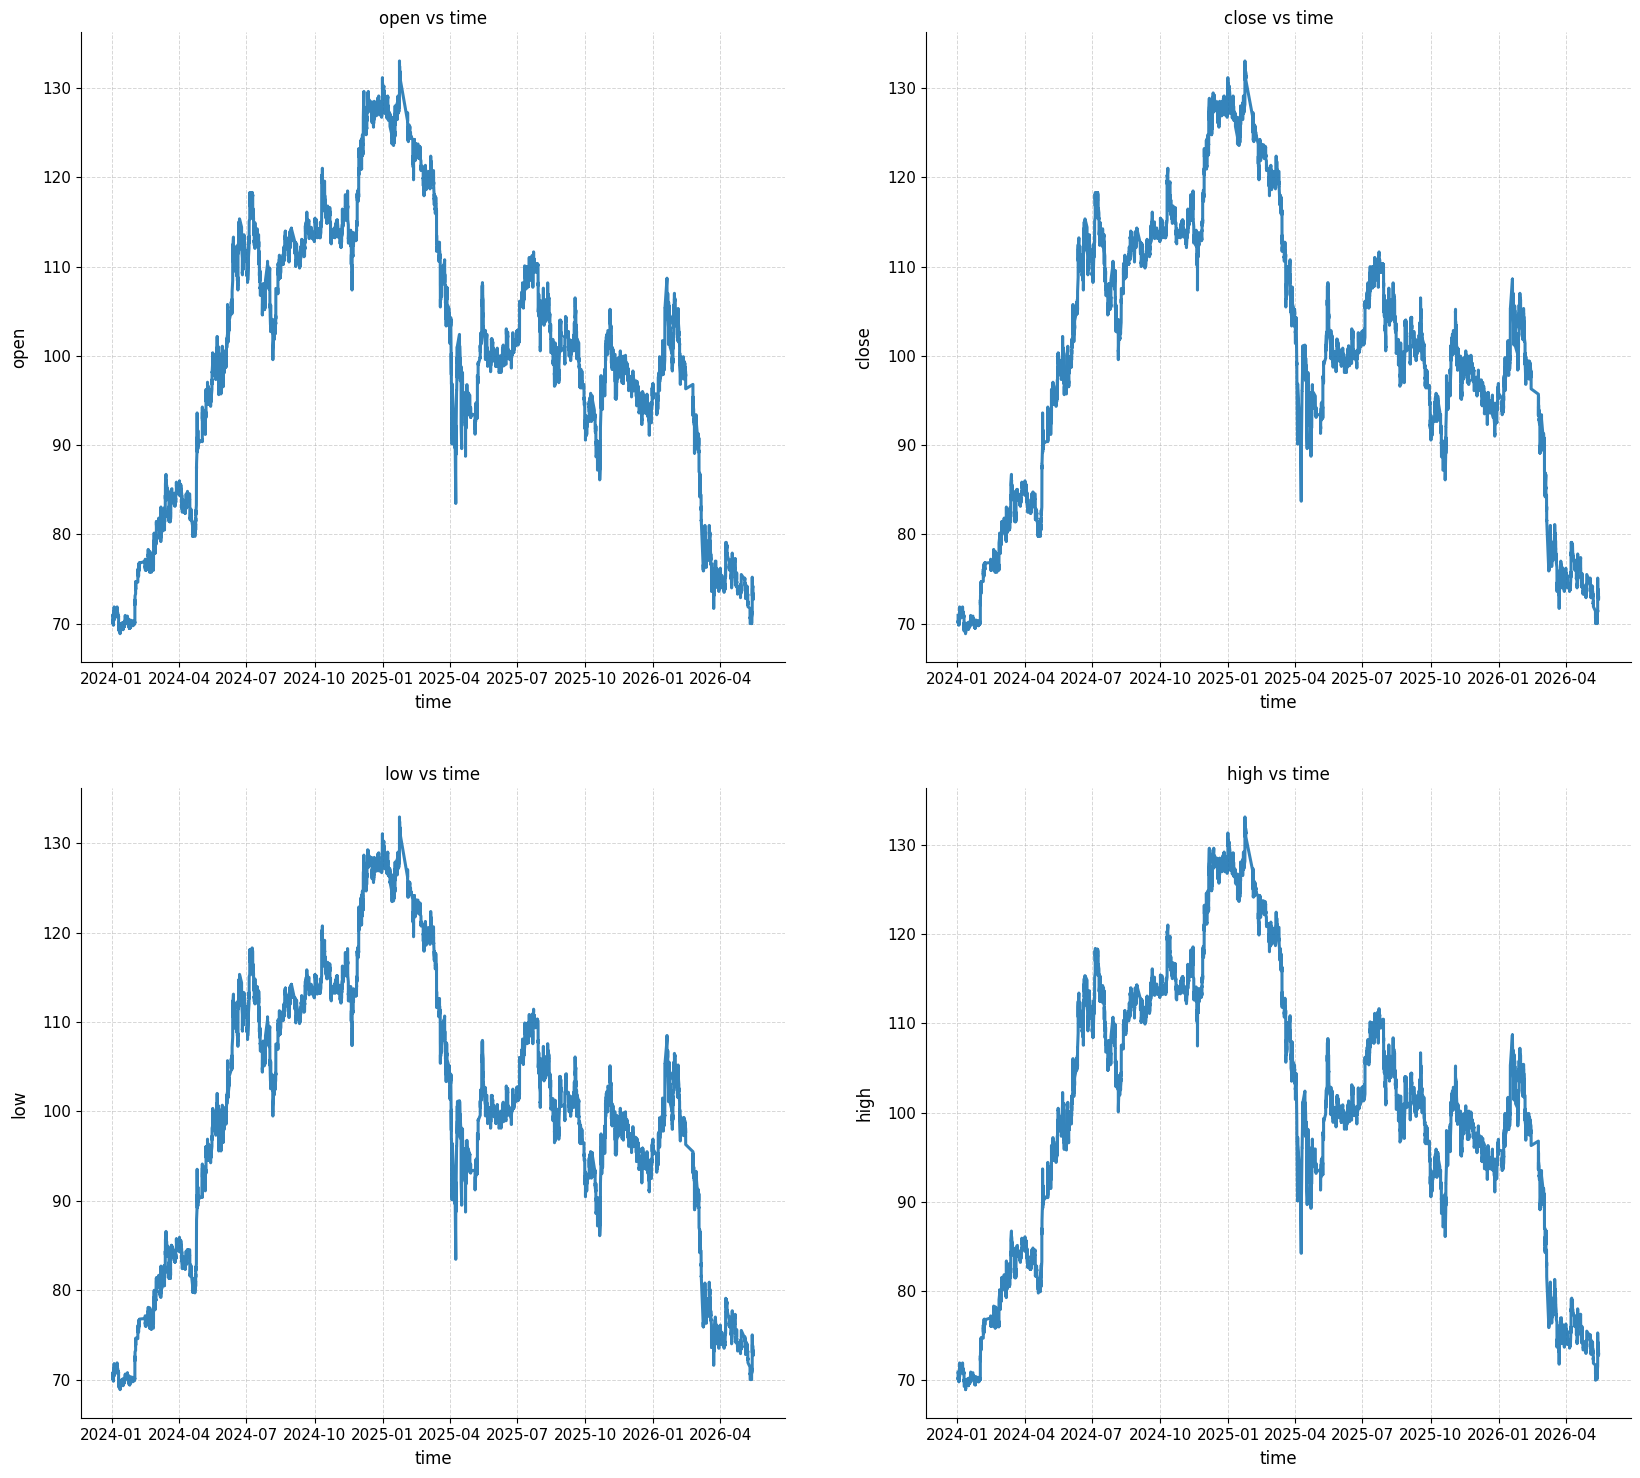

In [38]:
x_axis_list = ['time' for _ in range(4)]
y_axis_list = ['open', 'close', 'low', 'high']
hue_list = [None for _ in range(4)]
style_list = [None for _ in range(4)]
size_list = [None for _ in range(4)]

fig, axes = line_plotter.multiple_plots(x_axis_list=x_axis_list, y_axis_list=y_axis_list, hue_list=hue_list,
                                      style_list=style_list, size_list=size_list, plots_each_row=2,
                                      kwarg={}, readable_label=False)

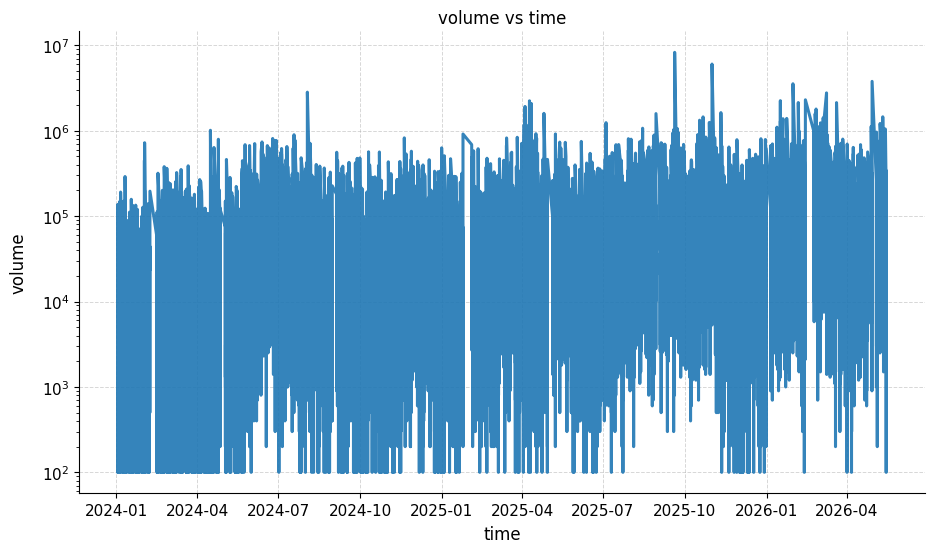

In [79]:
x_axis_list = ['time' for _ in range(1)]
y_axis_list = ['volume']
hue_list = [None for _ in range(1)]
style_list = [None for _ in range(1)]
size_list = [None for _ in range(1)]

fig, axes = line_plotter.multiple_plots(x_axis_list=x_axis_list, y_axis_list=y_axis_list, hue_list=hue_list,
                                      style_list=style_list, size_list=size_list, plots_each_row=2,
                                      kwarg={}, readable_label=False)

for ax in axes.flatten():
    ax.set_yscale('log')

fig.set_size_inches(24, 6)

In [90]:
box_plotter = BoxPlot(data)

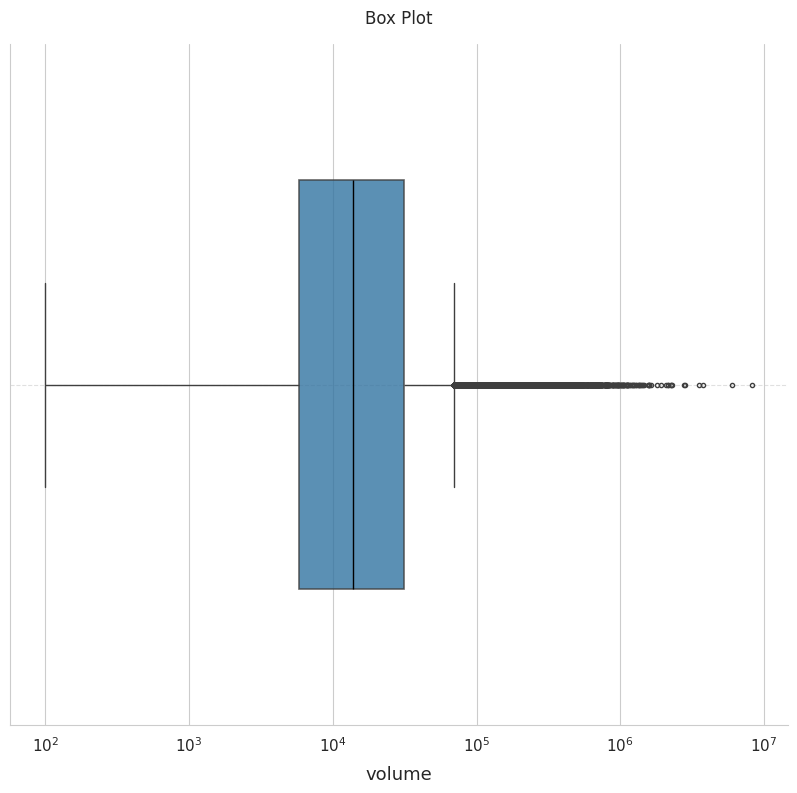

In [94]:
x_axis_list = ['volume']
y_axis_list=[None]
hue_list = [None]

fig, axes = box_plotter.multiple_plots(y_axis_list=y_axis_list, plots_each_row=2,
                      x_axis_list=x_axis_list, hue_list=hue_list, readable_label=False, 
                                   kwarg={})

for ax in axes.flatten():
    ax.set_xscale('log')

In [110]:
class ScatterPlot:
    def __init__(self, df:pd.DataFrame):
        self.df = df

    @staticmethod
    def readable_numbers(x: float) -> str:
        """
        takes a large number and formats it into K,M to make it more readable

        Args
            x: float value to format

        Returns
            str: formatted string
        """
        if x >= 1e6:
            s = '{:1.2f}M'.format(x*1e-6)
        else:
            s = '{:1.2f}K'.format(x*1e-3)
        return s
    
    def set_locator(self, axes: Axes):
        """
        Format x, y ticklabels into more readable form

        Args
            axes: matplotlib axes to format x, y ticklabels
        """
        def is_number(x):
            x = x.replace('−', '-')
            try:
                float(x)
                return True
            except ValueError:
                return False
    
        x_ticklabels = [tick.get_text() for tick in axes.get_xticklabels()]
        y_ticklabels = [tick.get_text() for tick in axes.get_yticklabels()]
    
        formatter = FuncFormatter(lambda val, pos: self.readable_numbers(val))

        if is_number(x_ticklabels[0]) == True:
            axes.xaxis.set_major_formatter(formatter)
        if is_number(y_ticklabels[0]) == True:
            axes.yaxis.set_major_formatter(formatter)
    
    def single_plot(self, x_axis: str, y_axis: str, hue: str|None, size: str|None, style: str|None, 
                    kwarg: dict|None = None, readable_label: bool = False, ax: Axes = None) -> Axes:
        """
        Draw single plot

        Args
            x_axis
            y_axis
            hue: column to group
            size: column to group
            style: column to group
            readable_label: whether if formatting x, y ticklabels
            ax: matplotlib axes to draw plot
            kwarg: other keyword arguments if needed
        """
        
        if ax is None:
            ax = plt.gca()
        if kwarg is None:
            kwarg = {}

        s = max(0.5, 20*(1000/len(self.df)))
        
        # --- Plot scatter ---
        scatter = sns.scatterplot(
            data=self.df, 
            x=x_axis, 
            y=y_axis, 
            hue=hue, 
            size=size, 
            style=style, 
            ax=ax, 
            edgecolor="black",       # add borders around points
            linewidth=0.6, 
            alpha=0.5,               # transparency for readability
            s=0.8,
            **kwarg
        )
        
        # --- Titles & labels ---
        ax.set_title(
            f"{y_axis} vs {x_axis}",
            fontdict={
                "fontsize": 12, 
                "fontweight": "bold", 
                # "fontname": "Times New Roman"
            },
            pad=15
        )
        ax.set_xlabel(f"{x_axis}", fontsize=10, labelpad=8)
        ax.set_ylabel(f"{y_axis}", fontsize=10, labelpad=8)
    
        # --- Grid & ticks ---
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.tick_params(axis="x", labelrotation=0, labelsize=10)
        ax.tick_params(axis="y", labelrotation=0, labelsize=10)
    
        # --- Legend improvement ---
        if hue or size or style:
            leg = ax.legend(
                loc="best",
                frameon=True,
                fancybox=True,
                framealpha=0.8,
                title="Legend",
                title_fontsize=12,
                fontsize=11
            )
            leg.get_frame().set_linewidth(0.5)
        
        # --- Optional: readable tick formatting ---
        if readable_label:
            self.set_locator(ax)
    
        # --- Aesthetic tweaks ---
        sns.despine(ax=ax, top=True, right=True)
    
        return scatter

    def multiple_plots(self, x_axis_list: list[str], y_axis_list: list[str], hue_list: list[str|None], size_list: list[str|None], kwarg: dict|None,
                    style_list: list[str|None], plots_each_row: int, readable_label: bool = False) -> (Figure, np.array([Axes])):
        """
        Draw multiple plots

        Args
            Same as single_plot
            y_axis_list: list of columns for y axis
            plots_each_row: number of plots for each row in matplotlib figure
            kwarg: other keyword arguments if needed
        """
        
        combination = list(zip(x_axis_list, y_axis_list, hue_list, size_list, style_list))

        length = len(combination)
        number_rows = math.ceil(length / plots_each_row)
    
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),
                                ) #sharey=True: same y_axis scale
        axes = np.array(axes).reshape(number_rows, plots_each_row)
    
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
        for coor, com in zip(coordinates, combination):
            x, y, hue, size, style = com
            ax = axes[coor]
            self.single_plot(
                x_axis=x,
                y_axis=y,
                hue=hue,
                size=size,
                style=style,
                readable_label=readable_label,
                kwarg=kwarg,
                ax=ax
            )
    
        # hide any unused axes
        for coor in coordinates[length:]:
            fig.delaxes(axes[coor])
    
        fig.tight_layout()

        return fig, axes

In [111]:
scatter_plotter = ScatterPlot(data)

In [97]:
data.head()

,time,open,high,low,close,volume
0,2024-01-02 09:15:00,70.92,70.92,70.40,70.92,51200
1,2024-01-02 09:16:00,70.92,70.92,70.62,70.62,6700
2,2024-01-02 09:17:00,70.62,70.70,70.62,70.70,1200
3,2024-01-02 09:18:00,70.70,70.84,70.70,70.70,1400
4,2024-01-02 09:19:00,70.70,70.70,70.70,70.70,16500


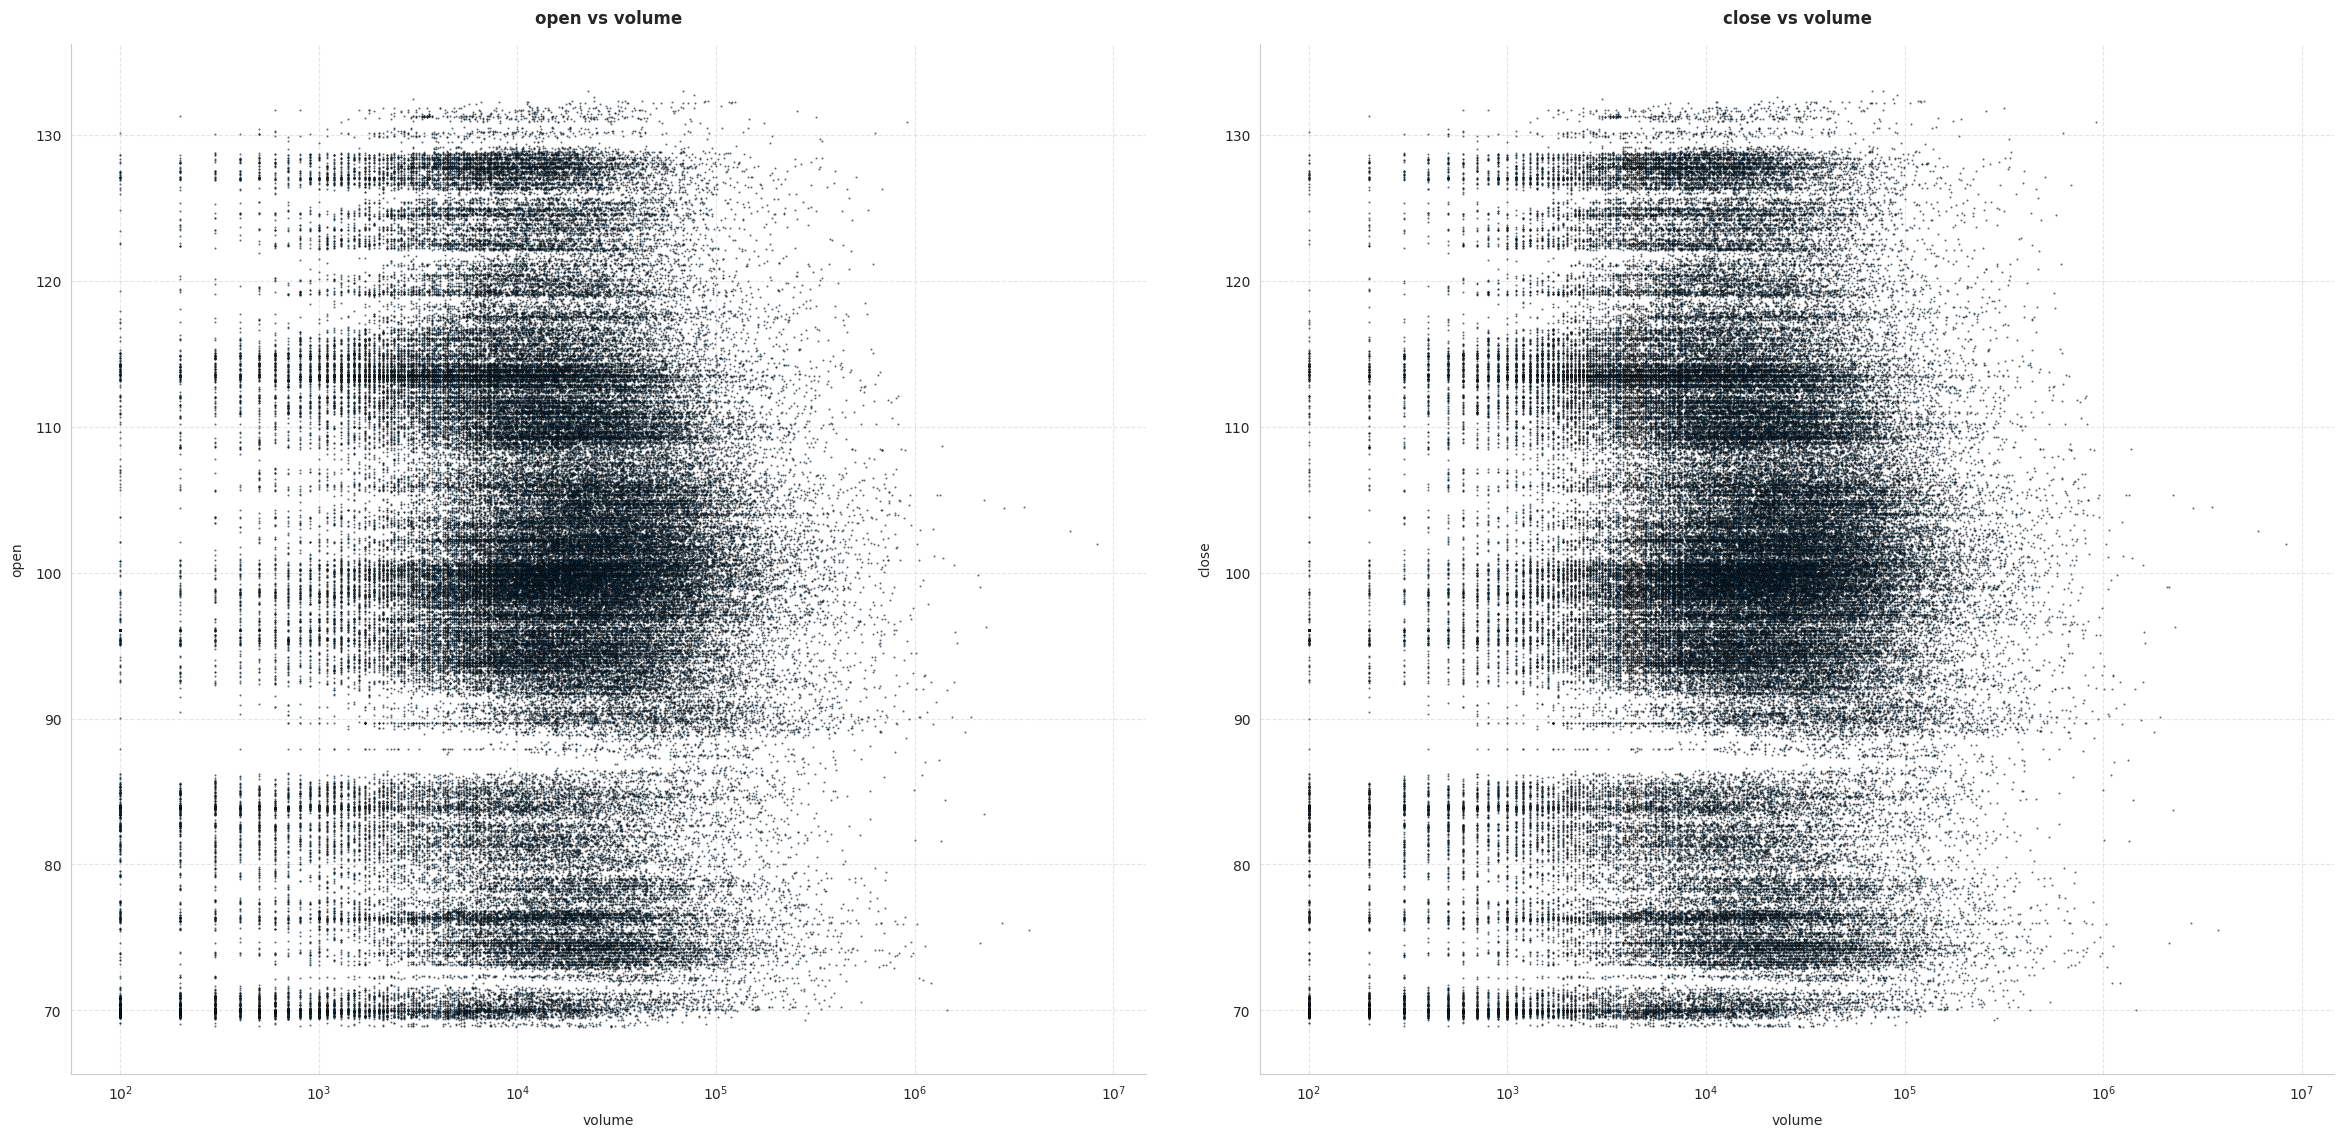

In [114]:
x_axis_list = ['volume' for _ in range(2)]
y_axis_list = ['open', "close"]
style_list = [None for _ in range(2)]
hue_list = [None for _ in range(2)]
size_list = [None for _ in range(2)]

fig, axes = scatter_plotter.multiple_plots(x_axis_list=x_axis_list, y_axis_list=y_axis_list, hue_list=hue_list, size_list=size_list, 
                    style_list=style_list, plots_each_row=2, readable_label=False, kwarg={})

for ax in axes.flatten():
    ax.set_xscale('log')

fig.set_size_inches(24, 12)

In [115]:
data.head()

,time,open,high,low,close,volume
0,2024-01-02 09:15:00,70.92,70.92,70.40,70.92,51200
1,2024-01-02 09:16:00,70.92,70.92,70.62,70.62,6700
2,2024-01-02 09:17:00,70.62,70.70,70.62,70.70,1200
3,2024-01-02 09:18:00,70.70,70.84,70.70,70.70,1400
4,2024-01-02 09:19:00,70.70,70.70,70.70,70.70,16500


In [116]:
class KDEPlot:
    """
    Create single and multiple box plots
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df

    @staticmethod
    def readable_numbers(x: float) -> str:
        """
        takes a large number and formats it into K,M to make it more readable

        Args
            x: float value to format

        Returns
            str: formatted string
        """
        if x >= 1e6:
            s = '{:1.1f}M'.format(x*1e-6)
        elif x >= 1e3:
            s = '{:1.1f}K'.format(x*1e-3)
        else:
            s = x
        return s

    def set_locator(self, axes: Axes):
        """
        Format x, y ticklabels into more readable form

        Args
            axes: matplotlib axes to format x, y ticklabels
        """
        def is_number(x):
            x = x.replace('−', '-')
            try:
                float(x)
                return True
            except ValueError:
                return False
    
        x_ticklabels = [tick.get_text() for tick in axes.get_xticklabels()]
        y_ticklabels = [tick.get_text() for tick in axes.get_yticklabels()]

        formatter = FuncFormatter(lambda val, pos: self.readable_numbers(val))

        if is_number(x_ticklabels[1]) == True:
            axes.xaxis.set_major_formatter(formatter)
        if is_number(y_ticklabels[1]) == True:
            axes.yaxis.set_major_formatter(formatter)

    def single_plot(
        self,
        x_axis: str,
        y_axis: str | None,
        hue: str | None,
        kwarg: dict | None = None,
        readable_label: bool = False,
        ax: Axes = None
    ) -> Axes:
        """
        Draw a beautiful and readable Box Plot.
    
        Args:
            x_axis: column needed
            y_axis: column needed
            hue: column needed
            dimension: '1d' for single variable, '2d' for grouped boxplot
            readable_label: whether to format x/y tick labels for readability
            ax: matplotlib axes to draw plot
            kwarg: additional seaborn arguments
        """
        
        if ax is None:
            ax = plt.gca()
        if kwarg is None:
            kwarg = {}
            
        # --- Styling palette and defaults ---
        sns.set_style("whitegrid")  # clean background
        palette = sns.color_palette('pastel')
        # or: "rocket", "magma", "coolwarm", "crest", "flare", "viridis"

        if hue is None:
            palette = None
        
        kde = sns.kdeplot(
            data=self.df,
            x=x_axis,
            y=y_axis,
            hue=hue,
            ax=ax,
            palette=palette,
            **kwarg
        )

        
        ax.set_xlabel(x_axis, fontsize=13, labelpad=8)
        ax.set_ylabel(y_axis, fontsize=13, labelpad=8)

        # if hue is not None:
        #     ax.legend(
        #         title=hue if hue else "",
        #         frameon=True,
        #         fancybox=True,
        #         framealpha=0.8,
        #         fontsize=11,
        #         title_fontsize=12,
        #         loc="best",
        #     )
    
        # --- Titles & Ticks ---
        ax.set_title(
            f"KDE Plot",
            fontdict={"fontsize": 12, "fontweight": "regular", 
                      # "fontname": "Times New Roman"
                     },
            pad=15
        )
        ax.tick_params(axis="x", labelrotation=0, labelsize=11)
        ax.tick_params(axis="y", labelrotation=0, labelsize=11)
    
        # --- Optional: readable tick labels ---
        if readable_label:
            self.set_locator(ax)
    
        # --- Clean up look ---
        sns.despine(ax=ax, top=True, right=True)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
    
        return kde
    
    def multiple_plots(self, y_axis_list: list[str|None], x_axis_list: list[str], kwarg: dict|None,
                       hue_list: list[str|None], plots_each_row: int, 
                       readable_label: bool = False) -> (Figure, np.array([Axes])):
        """
        Draw multiple box plots
        
        Args
            Same as single_plot
            y_axis_list: list of columns for y axis
            plots_each_row: number of plots for each row in matplotlib figure
        """
        combination = list(zip(x_axis_list, y_axis_list, hue_list))
        
        length = len(combination)
        number_rows = math.ceil(length / plots_each_row)
    
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),
                                ) # sharey=True: same y_axis scale
        axes = np.array(axes).reshape(number_rows, plots_each_row)
    
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
        for coor, com in zip(coordinates, combination):
            x, y, hue = com
            ax = axes[coor]
            self.single_plot(
                x_axis=x,
                y_axis=y,
                hue=hue,
                readable_label=readable_label,
                kwarg=kwarg,
                ax=ax
            )
    
        # hide any unused axes
        for coor in coordinates[length:]:
            fig.delaxes(axes[coor])
    
        fig.tight_layout()

        return fig, axes

In [118]:
plotter = KDEPlot(data)

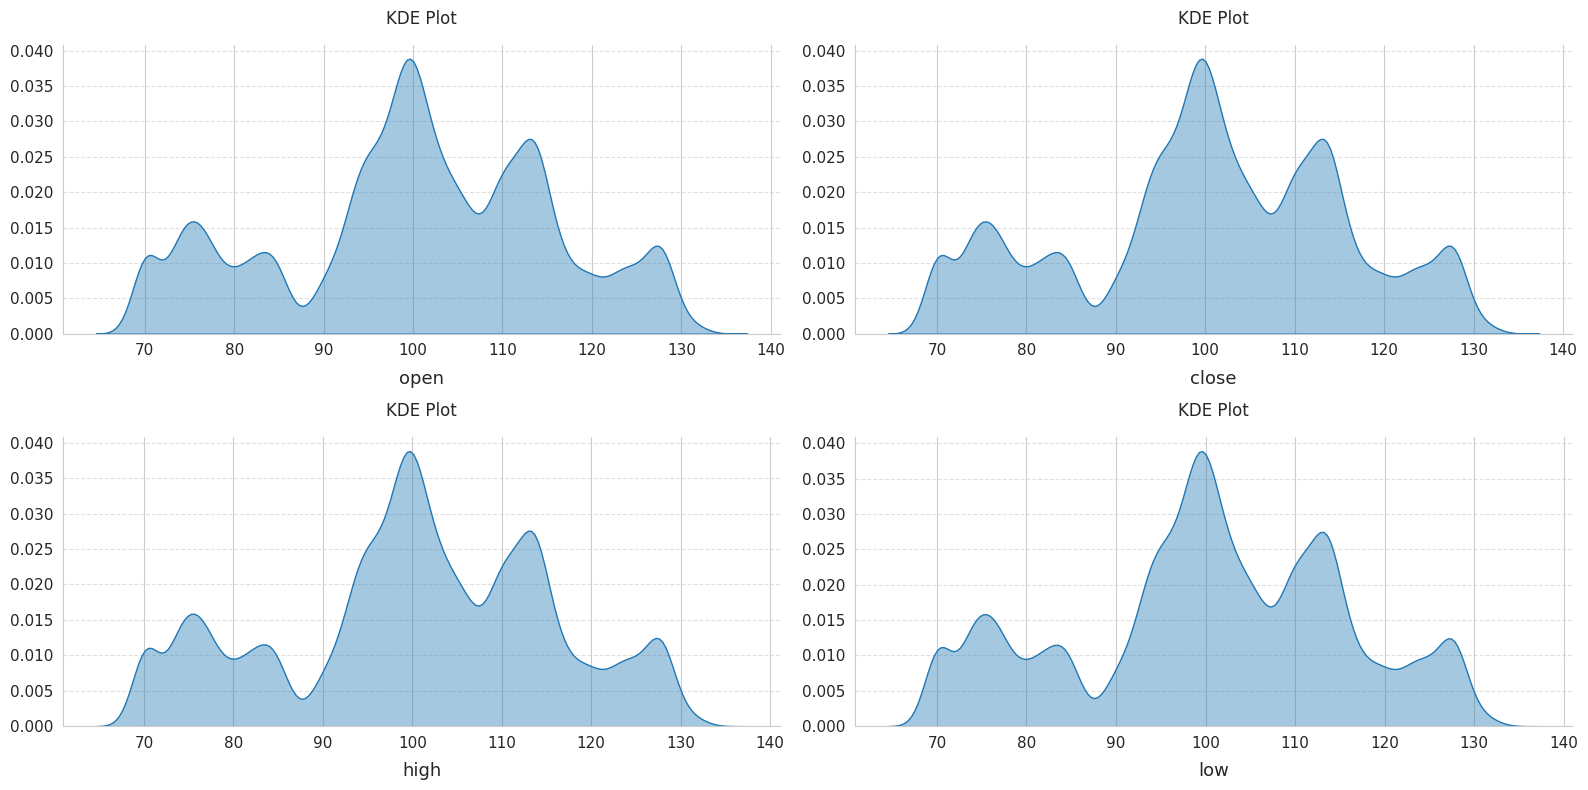

In [119]:
kde_arg = {
    'x_axis_list': ['open', 'close', 'high', 'low'],
    'y_axis_list': [None for _ in range(4)],
    'hue_list': [None for _ in range(4)],
    'readable_label': False,
    'plots_each_row': 2,
    'kwarg': dict(fill=True, alpha=0.4)
}

fig, kdes = plotter.multiple_plots(**kde_arg)

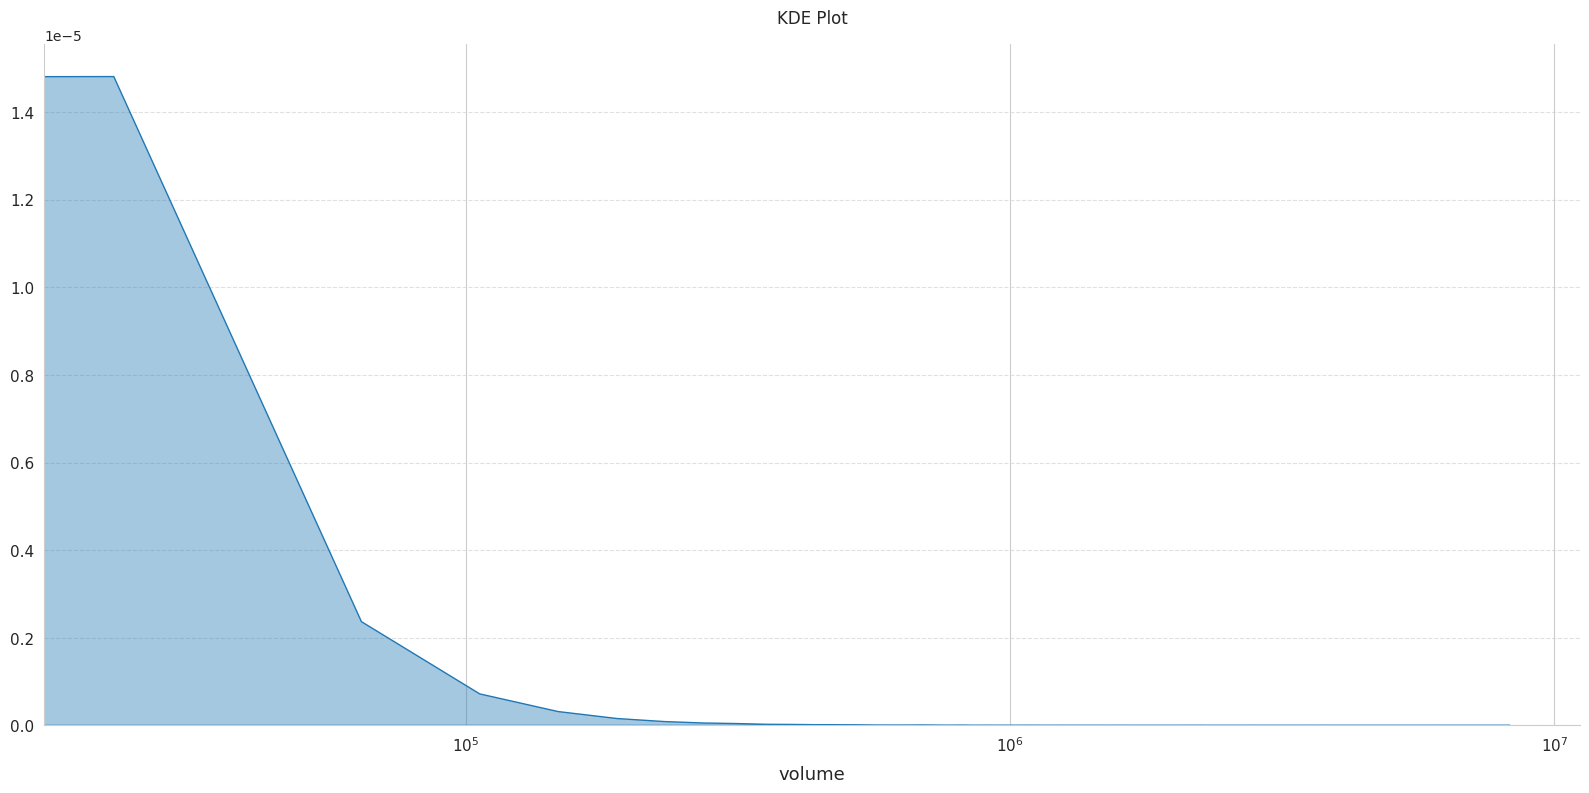

In [121]:
kde_arg = {
    'x_axis_list': ['volume'],
    'y_axis_list': [None for _ in range(1)],
    'hue_list': [None for _ in range(1)],
    'readable_label': False,
    'plots_each_row': 1,
    'kwarg': dict(fill=True, alpha=0.4)
}

fig, axes = plotter.multiple_plots(**kde_arg)

for ax in axes.flatten():
    ax.set_xscale('log')